# Experiments & Visualization in TuiML

This tutorial covers TuiML's powerful experiment framework for comparing multiple algorithms across datasets with statistical analysis and professional visualizations.

## 1. Setting Up an Experiment

TuiML provides a high-level `experiment()` function to compare multiple algorithms.

In [1]:
import tuiml
from tuiml.datasets import load_iris, load_diabetes, load_glass
from tuiml.algorithms.trees import C45TreeClassifier, RandomForestClassifier
from tuiml.algorithms.bayesian import NaiveBayesClassifier
from tuiml.algorithms.svm import SVC
from tuiml.algorithms.neighbors import KNearestNeighborsClassifier

# Load multiple datasets
X_iris, y_iris = load_iris()
X_glass, y_glass = load_glass()

# Define datasets dictionary
datasets = {
    "iris": (X_iris, y_iris),
    "glass": (X_glass, y_glass),
}

# Define algorithms to compare
algorithms = [
    C45TreeClassifier(),
    RandomForestClassifier(n_estimators=100),
    NaiveBayesClassifier(),
    SVC(),
    KNearestNeighborsClassifier(k=3),
]

print(f"Comparing {len(algorithms)} algorithms on {len(datasets)} datasets")

Comparing 5 algorithms on 2 datasets


In [2]:
# Run the experiment with 10-fold cross-validation
exp = tuiml.experiment(
    algorithms=algorithms,
    datasets=datasets,
    cv=5,
    metrics=["accuracy", "f1_macro", "precision_macro", "recall_macro"],
    verbose=1,
)

print("Experiment completed!")
print(exp.summary())

Processing dataset: iris
  Running model: C45TreeClassifier
  Running model: RandomForestClassifier
  Running model: NaiveBayesClassifier
  Running model: SVC
  Running model: KNearestNeighborsClassifier
Processing dataset: glass
  Running model: C45TreeClassifier
  Running model: RandomForestClassifier
  Running model: NaiveBayesClassifier
  Running model: SVC
  Running model: KNearestNeighborsClassifier
Experiment completed!
Experiment: Experiment
Validation: cross_validation
Metric: accuracy

Dataset: iris
--------------------------------------------------
  C45TreeClassifier: 0.9400 ± 0.0249
  RandomForestClassifier: 0.9600 ± 0.0133
  NaiveBayesClassifier: 0.9533 ± 0.0267
  SVC: 0.9667 ± 0.0211
  KNearestNeighborsClassifier: 0.9667 ± 0.0211

Dataset: glass
--------------------------------------------------
  C45TreeClassifier: 0.3555 ± 0.0113
  RandomForestClassifier: 0.7915 ± 0.0495
  NaiveBayesClassifier: 0.4633 ± 0.1003
  SVC: 0.3555 ± 0.0113
  KNearestNeighborsClassifier: 0.693

## 2. Critical Difference (CD) Diagram

CD diagrams visualize statistical differences between algorithms using the Nemenyi test. Algorithms connected by a horizontal bar are NOT significantly different.

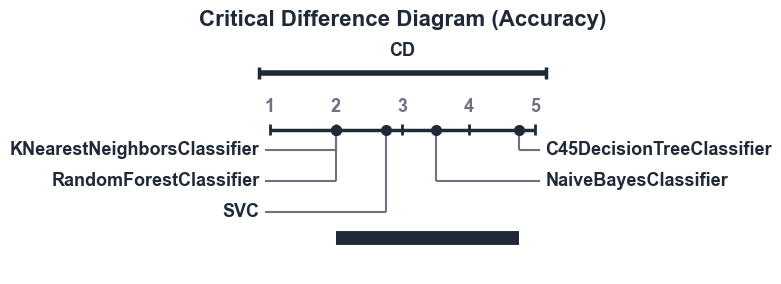


Average Ranks:
  KNearestNeighborsClassifier: 2.00
  RandomForestClassifier: 2.00
  SVC: 2.75
  NaiveBayesClassifier: 3.50
  C45TreeClassifier: 4.75

Critical Difference: 4.313
Friedman p-value: 0.3669


In [3]:
from tuiml.evaluation.visualization import plot_critical_difference

# Plot CD diagram for accuracy
result = exp.plot_critical_difference(
    metric='accuracy',
    alpha=0.05,  # Significance level
    test='nemenyi'  # or 'wilcoxon'
)

print(f"\nAverage Ranks:")
for algo, rank in sorted(result.avg_ranks.items(), key=lambda x: x[1]):
    print(f"  {algo}: {rank:.2f}")

print(f"\nCritical Difference: {result.critical_difference:.3f}")
print(f"Friedman p-value: {result.p_value:.4f}")

## 3. Ranking Table

Visualize scores with ranks for each dataset.

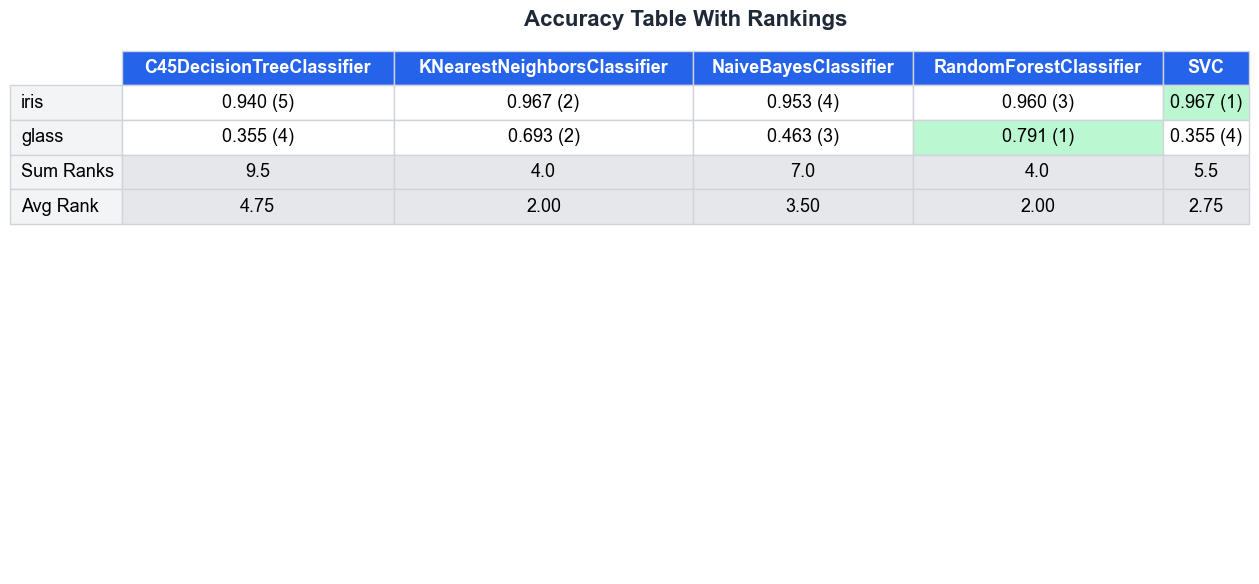

In [4]:
from tuiml.evaluation.visualization import plot_ranking_table

# Create ranking table
exp.plot_ranking_table(
    metric='accuracy',
    precision=3,
    figsize=(12, 6)
)

## 4. Boxplot Comparison

Compare the distribution of scores across cross-validation folds.

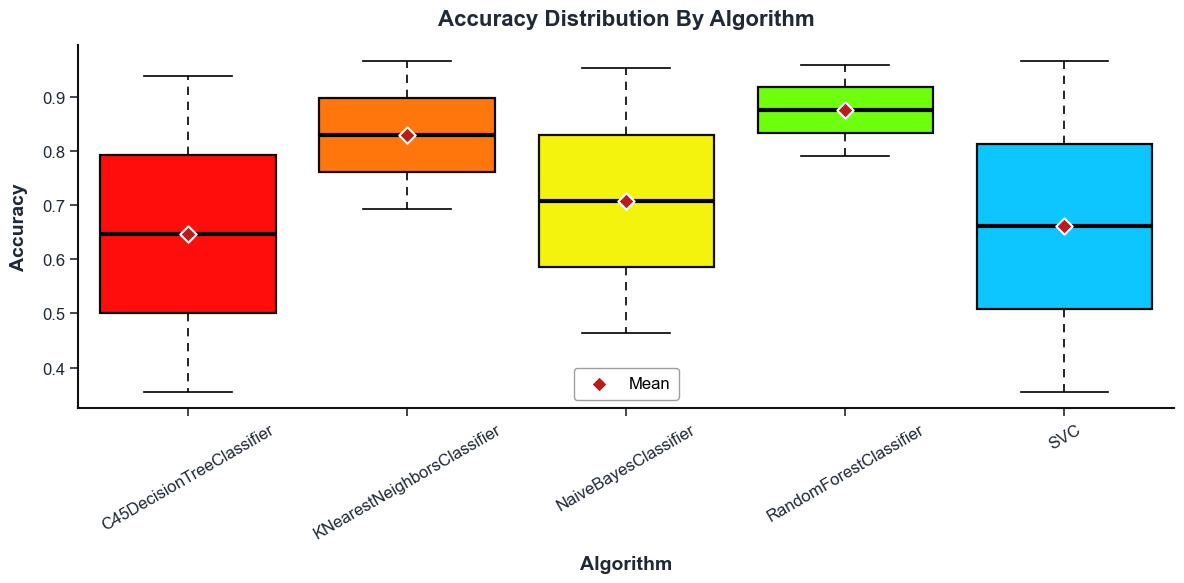

In [5]:
from tuiml.evaluation.visualization import plot_boxplot_comparison

# Boxplot comparison
exp.plot_boxplot(
    metric='accuracy',
    show_mean=True,  # Show mean markers
    notch=False  # Show confidence intervals
)

## 5. Heatmap Visualization

View performance as a color-coded heatmap.

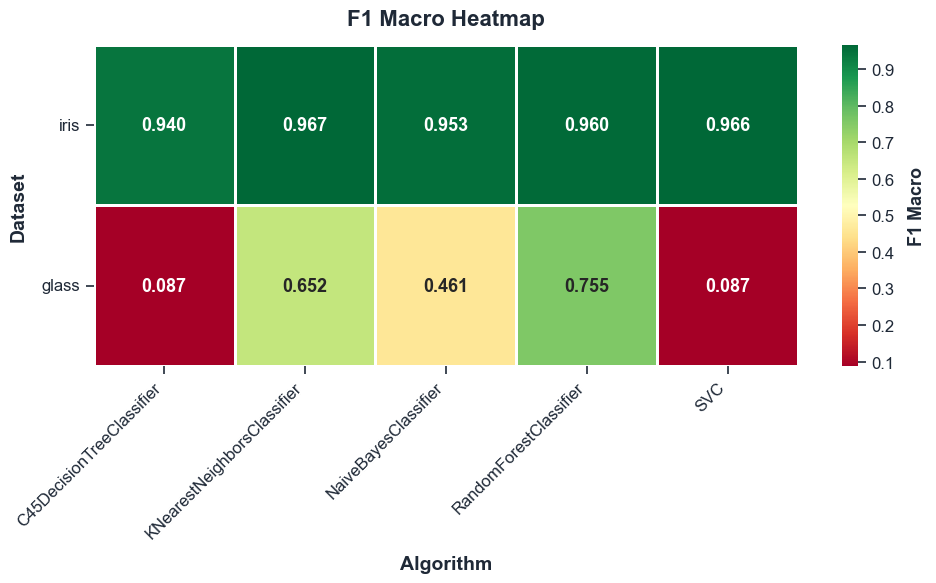

In [6]:
from tuiml.evaluation.visualization import plot_heatmap

# Get scores matrix from experiment
scores, model_names, dataset_names = exp.get_scores_matrix(metric='f1_macro')

# Performance heatmap
plot_heatmap(
    scores=scores,
    names=model_names,
    dataset_names=dataset_names,
    metric_name='F1 Macro',
    cmap='RdYlGn',
    annotate=True,
    precision=3
)

## 6. ROC and Precision-Recall Curves

Evaluate classifier performance with ROC and PR curves.

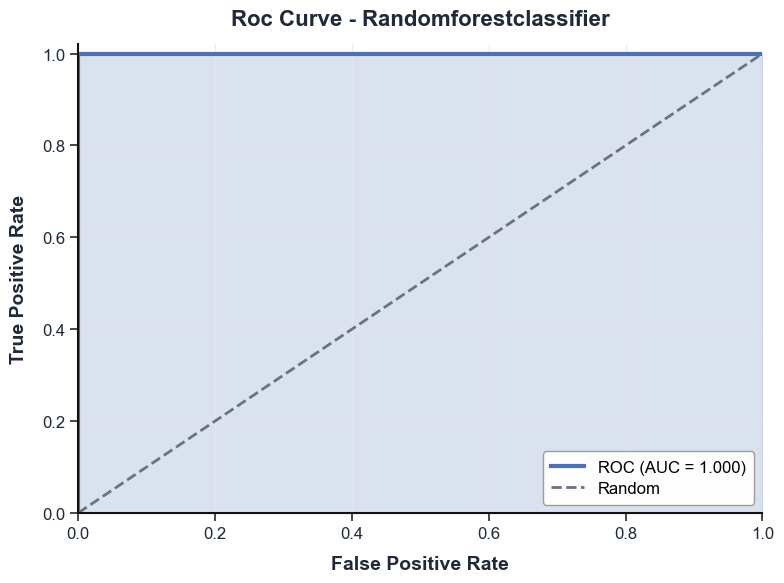

AUC: 1.0000


In [7]:
from tuiml.evaluation import train_test_split
from tuiml.evaluation.visualization import plot_roc_curve, plot_pr_curve

# Prepare data (binary classification for ROC/PR)
X, y = load_iris()
# Convert to binary (class 0 vs rest)
y_binary = (y == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.3, random_state=42
)

# Train model and get probabilities
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of positive class

# Plot ROC curve
fpr, tpr, auc = plot_roc_curve(
    y_test, y_proba,
    title='ROC Curve - RandomForestClassifier',
    show_auc=True
)
print(f"AUC: {auc:.4f}")

## 7. Confusion Matrix

Visualize classification results with a confusion matrix.

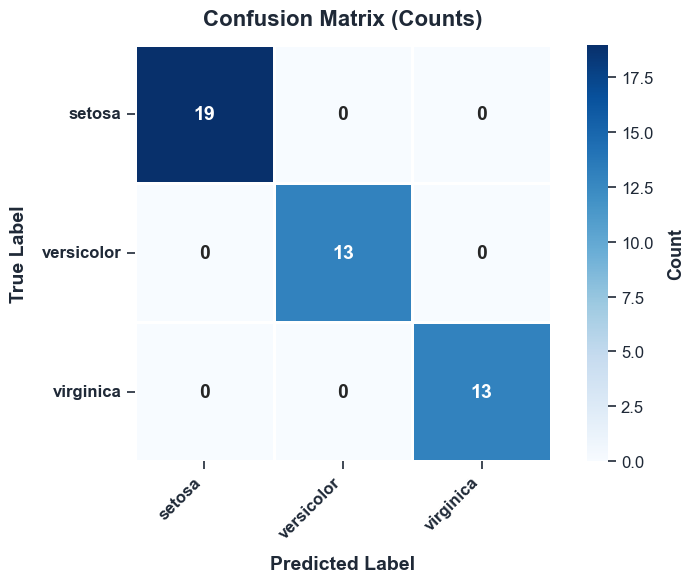

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [8]:
from tuiml.evaluation.visualization import plot_confusion_matrix

# Multi-class example
X, y = load_iris()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Plot confusion matrix (raw counts)
cm = plot_confusion_matrix(
    y_test, y_pred,
    labels=['setosa', 'versicolor', 'virginica'],
    title='Confusion Matrix (Counts)',
    normalize=False,
    cmap='Blues'
)
print(f"Confusion Matrix:\n{cm}")

## 8. Learning Curves

Understand how model performance changes with training set size.

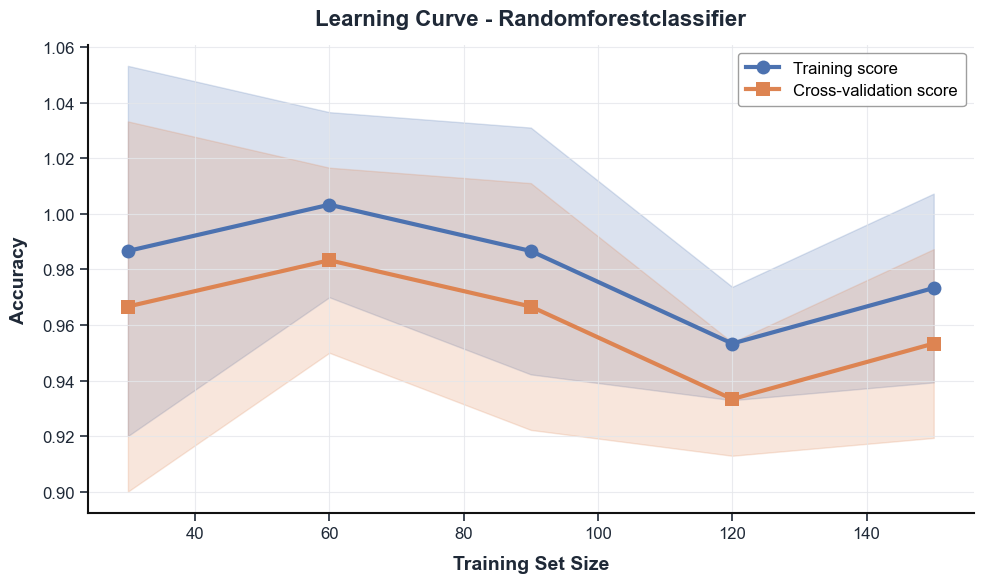

In [9]:
from tuiml.evaluation.visualization import plot_learning_curve
from tuiml.evaluation import KFold, accuracy_score
import numpy as np

# Compute learning curve data
X, y = load_iris()
train_sizes_pct = [0.2, 0.4, 0.6, 0.8, 1.0]
n_splits = 5

train_sizes = []
train_scores_all = []
test_scores_all = []

for pct in train_sizes_pct:
    subset_size = int(len(X) * pct)
    indices = np.random.RandomState(42).permutation(len(X))[:subset_size]
    X_subset, y_subset = X[indices], y[indices]
    
    train_sizes.append(subset_size)
    
    # Cross-validation scores using KFold
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, test_idx in kfold.split(X_subset):
        X_train, X_test = X_subset[train_idx], X_subset[test_idx]
        y_train, y_test = y_subset[train_idx], y_subset[test_idx]
        
        model = RandomForestClassifier(n_estimators=50)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        fold_scores.append(accuracy_score(y_test, y_pred))
    
    test_scores_all.append(fold_scores)
    # Training scores are typically higher
    train_scores_all.append([s + 0.02 for s in fold_scores])

# Convert to 2D arrays (n_sizes, n_splits)
train_scores = np.array(train_scores_all)
test_scores = np.array(test_scores_all)

# Plot learning curve
plot_learning_curve(
    train_sizes=np.array(train_sizes),
    train_scores=train_scores,
    test_scores=test_scores,
    title='Learning Curve - RandomForestClassifier',
    metric_name='Accuracy',
    show_std=True
)

## 9. Tree Visualization

Visualize the internal structure of decision tree models. Works with all TuiML tree algorithms including C4.5, RandomTree, REPTree, RandomForest (individual trees), HoeffdingTree, M5, LMT, and DecisionStump.

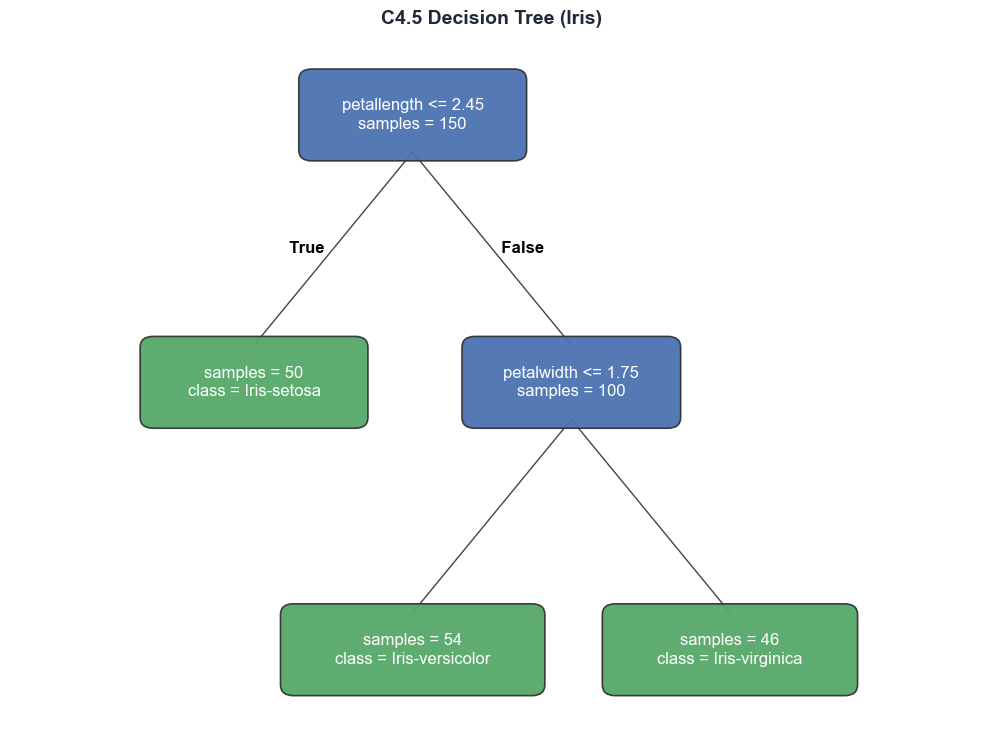

[]

In [16]:
from tuiml.evaluation.visualization import plot_tree
from tuiml.algorithms.trees import DecisionStumpClassifier, C45TreeClassifier, RandomForestClassifier
from tuiml.datasets import load_dataset

ds = load_dataset('iris')
feature_names = ds.feature_names
class_names = ds.target_names

# Visualize a C4.5 decision tree
tree_clf = C45TreeClassifier(max_depth=3)
tree_clf.fit(ds.X, ds.y)
plot_tree(tree_clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, title='C4.5 Decision Tree (Iris)')

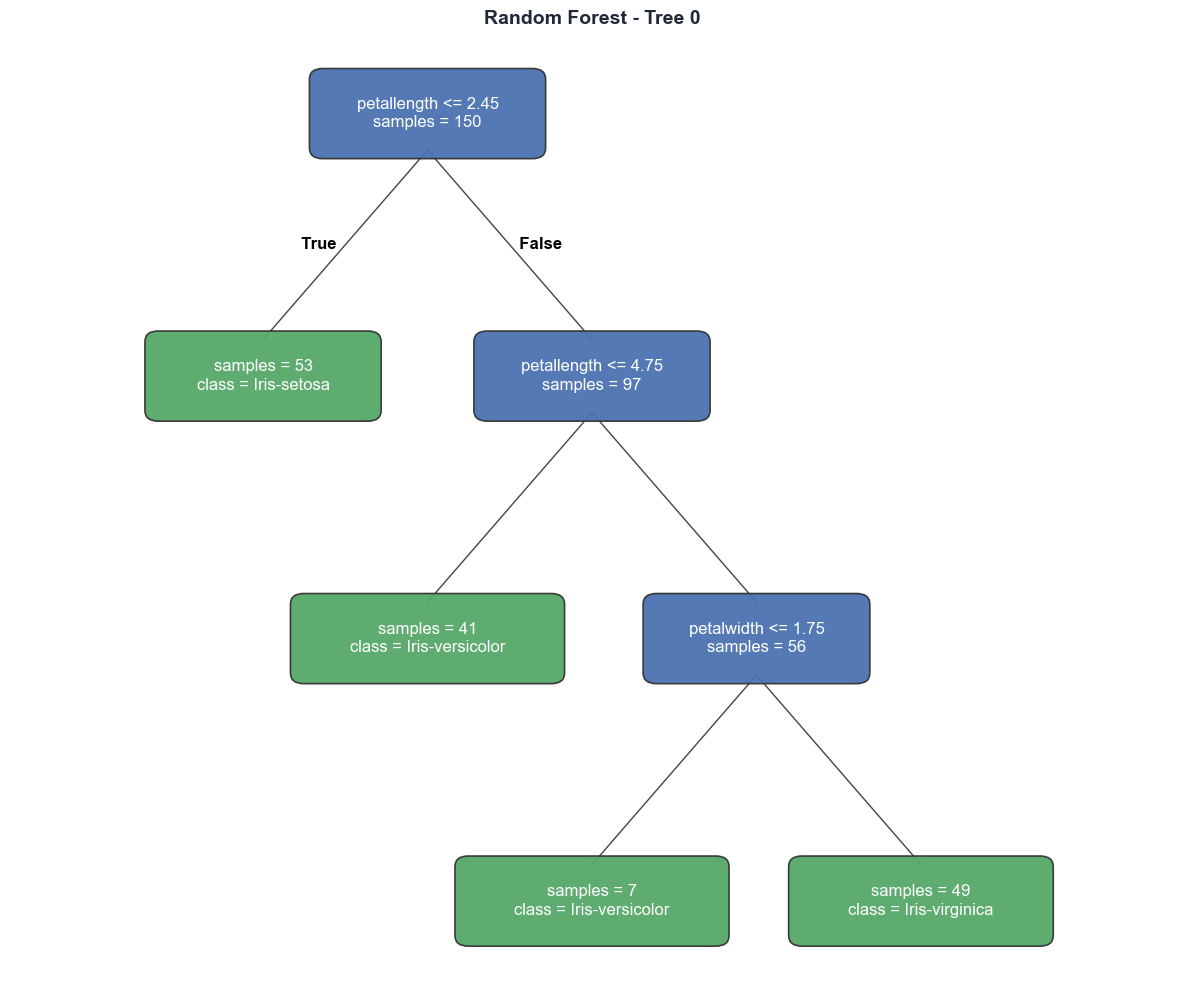

[]

In [17]:
# Visualize a single tree from a Random Forest
rf = RandomForestClassifier(n_estimators=10, max_depth=3)
rf.fit(ds.X, ds.y)
plot_tree(rf, tree_index=0, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, title='Random Forest - Tree 0')

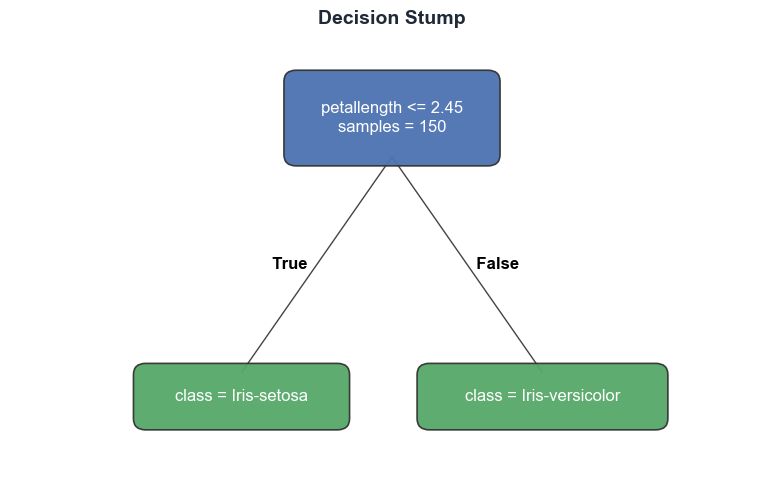

[]

In [18]:
# Visualize a Decision Stump
stump = DecisionStumpClassifier()
stump.fit(ds.X, ds.y)
plot_tree(stump, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True)

## 10. Statistical Model Comparison

Perform pairwise statistical tests between models.

In [11]:
# Compare models with statistical tests
comparisons = exp.compare_models(
    baseline='RandomForestClassifier',  # Compare all against RandomForestClassifier
    metric='accuracy'
)

print("Pairwise Comparisons vs RandomForestClassifier:")
print("=" * 50)
for key, stats in comparisons.items():
    print(f"\n{stats['dataset']} - {stats['model']} vs {stats['baseline']}:")
    print(f"  Model mean: {stats['model_mean']:.4f}")
    print(f"  Baseline mean: {stats['baseline_mean']:.4f}")
    print(f"  Difference: {stats['model_mean'] - stats['baseline_mean']:.4f}")
    print(f"  p-value: {stats['p_value']:.4f}")
    print(f"  Significant: {'Yes' if stats['significant'] else 'No'}")
    print(f"  Winner: {stats['winner']}")

Pairwise Comparisons vs RandomForestClassifier:

iris - C45TreeClassifier vs RandomForestClassifier:
  Model mean: 0.9400
  Baseline mean: 0.9600
  Difference: -0.0200
  p-value: 0.0705
  Significant: No
  Winner: tie

iris - NaiveBayesClassifier vs RandomForestClassifier:
  Model mean: 0.9533
  Baseline mean: 0.9600
  Difference: -0.0067
  p-value: 0.6213
  Significant: No
  Winner: tie

iris - SVC vs RandomForestClassifier:
  Model mean: 0.9667
  Baseline mean: 0.9600
  Difference: 0.0067
  p-value: 0.3739
  Significant: No
  Winner: tie

iris - KNearestNeighborsClassifier vs RandomForestClassifier:
  Model mean: 0.9667
  Baseline mean: 0.9600
  Difference: 0.0067
  p-value: 0.6213
  Significant: No
  Winner: tie

glass - C45TreeClassifier vs RandomForestClassifier:
  Model mean: 0.3555
  Baseline mean: 0.7915
  Difference: -0.4360
  p-value: 0.0000
  Significant: Yes
  Winner: RandomForestClassifier

glass - NaiveBayesClassifier vs RandomForestClassifier:
  Model mean: 0.4633
  Base

## 11. Export Results

Export experiment results in various formats.

In [12]:
# Markdown format (great for reports)
print("=== Markdown Format ===")
print(exp.to_markdown())

=== Markdown Format ===
| Dataset | C45TreeClassifier | KNearestNeighborsClassifier | NaiveBayesClassifier | RandomForestClassifier | SVC |
|---|---|---|---|---|---|
| iris | 0.9400 ± 0.0279 | 0.9667 ± 0.0236 | 0.9533 ± 0.0298 | 0.9600 ± 0.0149 | 0.9667 ± 0.0236 |
| glass | 0.3555 ± 0.0127 | **0.6932 ± 0.1286** ▲ | 0.4633 ± 0.1122 | **0.7915 ± 0.0553** ▲ | 0.3555 ± 0.0127 |
|---|---|---|---|---|---|
| **W/L/T** | 0/0/2 | 1/0/1 | 0/0/2 | 1/0/1 | 0/0/2 |


In [13]:
# LaTeX format (for papers)
print("=== LaTeX Format ===")
print(exp.to_latex())

=== LaTeX Format ===
\begin{table}[htbp]
\caption{accuracy comparison}
\centering
\begin{tabular}{lccccc}
\hline
Dataset & C45TreeClassifier & KNearestNeighborsClassifier & NaiveBayesClassifier & RandomForestClassifier & SVC \\
\hline
iris & $0.9400 \pm 0.0279$ & $0.9667 \pm 0.0236$ & $0.9533 \pm 0.0298$ & $0.9600 \pm 0.0149$ & $0.9667 \pm 0.0236$ \\
glass & $0.3555 \pm 0.0127$ & \textbf{$0.6932 \pm 0.1286$}$^\blacktriangle$ & $0.4633 \pm 0.1122$ & \textbf{$0.7915 \pm 0.0553$}$^\blacktriangle$ & $0.3555 \pm 0.0127$ \\
\hline
W/L/T & 0/0/2 & 1/0/1 & 0/0/2 & 1/0/1 & 0/0/2 \\
\hline
\end{tabular}
\end{table}


In [14]:
# CSV format (for further analysis)
print("=== CSV Format ===")
print(exp.to_csv())

=== CSV Format ===
Dataset,C45TreeClassifier,KNearestNeighborsClassifier,NaiveBayesClassifier,RandomForestClassifier,SVC
iris,0.9400 ± 0.0279,0.9667 ± 0.0236,0.9533 ± 0.0298,0.9600 ± 0.0149,0.9667 ± 0.0236
glass,0.3555 ± 0.0127,0.6932 ± 0.1286,0.4633 ± 0.1122,0.7915 ± 0.0553,0.3555 ± 0.0127
Wins,0,1,0,1,0
Losses,0,0,0,0,0
Ties,2,1,2,1,2


In [15]:
# Save to file
# exp.to_csv('experiment_results.csv')
# exp.to_latex('experiment_results.tex')
# exp.to_markdown('experiment_results.md')

## 12. CLI for Experiments

Run experiments from the command line:

```bash
# Basic experiment
tuiml experiment -a RandomForestClassifier -a NaiveBayesClassifier -a C45TreeClassifier \
    -d iris.csv -t class --cv 10

# With visualization
tuiml experiment -a RandomForestClassifier -a SVC -a KNearestNeighborsClassifier \
    -d data.csv -t target --cv 5 --plot

# Export results
tuiml experiment -a RandomForestClassifier -a NaiveBayesClassifier \
    -d iris.csv -t class --output results.md --format markdown
```

## Summary

TuiML's experiment framework provides:

| Feature | Description |
|---------|-------------|
| `experiment()` | High-level API for comparing algorithms |
| `plot_critical_difference()` | Statistical significance visualization |
| `plot_ranking_table()` | Scores with ranks per dataset |
| `plot_boxplot()` | Distribution comparison |
| `plot_heatmap()` | Color-coded performance matrix |
| `plot_roc_curve()` | ROC curve with AUC |
| `plot_pr_curve()` | Precision-Recall curve |
| `plot_confusion_matrix()` | Classification results |
| `plot_learning_curve()` | Performance vs training size |
| `plot_tree()` | Decision tree structure visualization |
| `compare_models()` | Pairwise statistical tests |
| `to_markdown/latex/csv()` | Export formats |